In [1]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [2]:
!unzip -q "HAM_CLEAN_SPLIT.zip" -d /content/dataset

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

In [4]:
CLEAN_ROOT = "/content/dataset/HAM_CLEAN_SPLIT"
TRAIN_DIR  = os.path.join(CLEAN_ROOT, "train")
VAL_DIR    = os.path.join(CLEAN_ROOT, "val")
TEST_DIR   = os.path.join(CLEAN_ROOT, "test")

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR  :", VAL_DIR)
print("TEST_DIR :", TEST_DIR)


TRAIN_DIR: /content/dataset/HAM_CLEAN_SPLIT/train
VAL_DIR  : /content/dataset/HAM_CLEAN_SPLIT/val
TEST_DIR : /content/dataset/HAM_CLEAN_SPLIT/test


In [5]:
classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print("\nClasses:", classes)

print("\nCounts:")
for cls in classes:
    n_train = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    n_val   = len(os.listdir(os.path.join(VAL_DIR, cls)))
    n_test  = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f"{cls:6s} | Train: {n_train:4d} | Val: {n_val:4d} | Test: {n_test:4d}")



Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Counts:
akiec  | Train:  555 | Val:   49 | Test:   50
bcc    | Train:  350 | Val:   75 | Test:   75
bkl    | Train:  350 | Val:   75 | Test:   75
df     | Train:  504 | Val:   17 | Test:   18
mel    | Train:  350 | Val:   75 | Test:   75
nv     | Train:  350 | Val:   75 | Test:   75
vasc   | Train:  525 | Val:   21 | Test:   22


In [6]:
def count_aug(root):
    c = 0
    for cls in os.listdir(root):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fn in os.listdir(cls_dir):
            if "_aug_" in fn:
                c += 1
    return c

print("\nAugmented in VAL :", count_aug(VAL_DIR))
print("Augmented in TEST:", count_aug(TEST_DIR))


Augmented in VAL : 0
Augmented in TEST: 0


In [7]:
def show_random_images(root_dir, class_name, n=6):
    class_dir = os.path.join(root_dir, class_name)
    files_ = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
    if len(files_) == 0:
        print("No images found:", class_dir)
        return
    sample = random.sample(files_, min(n, len(files_)))

    cols = min(6, len(sample))
    rows = (len(sample) + cols - 1) // cols
    plt.figure(figsize=(cols*3, rows*3))
    for i, f in enumerate(sample):
        img = tf.keras.utils.load_img(os.path.join(class_dir, f), target_size=(224,224))
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(f"{class_name} ({os.path.basename(root_dir)})", fontsize=14)
    plt.show()

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
print("\nClass names:", class_names)
NUM_CLASSES = len(class_names)


Found 2984 files belonging to 7 classes.
Found 387 files belonging to 7 classes.
Found 390 files belonging to 7 classes.

Class names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [ ]:
mixed_precision.set_global_policy("mixed_float16")

AUTOTUNE = tf.data.AUTOTUNE
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_batch(x, y):
    x = tf.cast(x, tf.float32)  
    x = preprocess(x)
    return x, y

train_ds = train_ds.map(preprocess_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_batch,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_batch,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


In [ ]:

def h_sigmoid(x):
    return tf.nn.relu6(x + 3.0) / 6.0

def h_swish(x):
    return x * h_sigmoid(x)

@tf.keras.utils.register_keras_serializable(package="Custom")
class CoordAttFast(layers.Layer):
    
    def __init__(self, reduction=64, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        c = int(input_shape[-1])
        mip = max(8, c // self.reduction)
        self.conv1  = layers.Conv2D(mip, 1, padding="same", use_bias=True)  # bias=True replaces BN
        self.conv_h = layers.Conv2D(c,   1, padding="same", use_bias=True)
        self.conv_w = layers.Conv2D(c,   1, padding="same", use_bias=True)
        super().build(input_shape)

    def call(self, x):
        h = tf.shape(x)[1]
        w = tf.shape(x)[2]

        x_h = tf.reduce_mean(x, axis=2, keepdims=True)  
        x_w = tf.reduce_mean(x, axis=1, keepdims=True)  
        x_w = tf.transpose(x_w, [0, 2, 1, 3])           

        y = tf.concat([x_h, x_w], axis=1)              
        y = h_swish(self.conv1(y))

        y_h, y_w = tf.split(y, [h, w], axis=1)
        y_w = tf.transpose(y_w, [0, 2, 1, 3])          

        a_h = tf.sigmoid(self.conv_h(y_h))             
        a_w = tf.sigmoid(self.conv_w(y_w))              
        return x * a_h * a_w

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction": self.reduction})
        return cfg


In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

x = CoordAttFast(reduction=64, name="coord_att_fast")(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = keras.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ coord_att_fast (CoordAttFast)   │ (None, 7, 7, 1280)     │        79,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,346,331 (8.95 MB)

 Trainable params: 88,347 (345.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_1 = [
    keras.callbacks.ModelCheckpoint("mobilenetv2_coordatt_best.keras", monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_1
)


Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 99s 652ms/step - accuracy: 0.4068 - loss: 1.5534 - val_accuracy: 0.5297 - val_loss: 1.2489 - learning_rate: 0.0010
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6689 - loss: 0.9017 - val_accuracy: 0.5556 - val_loss: 1.1964 - learning_rate: 0.0010
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7244 - loss: 0.7506 - val_accuracy: 0.5736 - val_loss: 1.1457 - learning_rate: 0.0010
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7491 - loss: 0.6692 - val_accuracy: 0.5943 - val_loss: 1.1404 - learning_rate: 0.0010
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7761 - loss: 0.6021 - val_accuracy: 0.5943 - val_loss: 1.1569 - learning_rate: 0.0010
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7994 - loss: 0.5384 - val_accuracy: 0.5917 - val_loss: 1.1693 - learning_rate: 0.0010
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8372 - loss: 0.4612 - val_a

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("mobilenetv2_coordatt_best.keras", monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
]

model = tf.keras.models.load_model("mobilenetv2_coordatt_best.keras")


base_model = next(
    l for l in model.layers
    if isinstance(l, tf.keras.Model) and "mobilenetv2" in l.name.lower()
)

base_model.trainable = True


for layer in base_model.layers[:-54]:
    layer.trainable = False


for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 128s 772ms/step - accuracy: 0.5719 - loss: 1.3306 - val_accuracy: 0.5659 - val_loss: 1.2604 - learning_rate: 1.0000e-04
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7326 - loss: 0.6989 - val_accuracy: 0.5297 - val_loss: 1.4099 - learning_rate: 1.0000e-04
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7590 - loss: 0.6418 - val_accuracy: 0.5736 - val_loss: 1.2301 - learning_rate: 1.0000e-04
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8092 - loss: 0.4986 - val_accuracy: 0.5995 - val_loss: 1.0263 - learning_rate: 1.0000e-04
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8674 - loss: 0.3404 - val_accuracy: 0.6486 - val_loss: 1.1415 - learning_rate: 1.0000e-04
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8924 - loss: 0.2859 - val_accuracy: 0.6434 - val_loss: 0.9699 - learning_rate: 1.0000e-04
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.92

In [14]:
best_model = keras.models.load_model("mobilenetv2_coordatt_best.keras")
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"\nCLEAN Test accuracy: {test_acc:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6830 - loss: 1.3281

CLEAN Test accuracy: 0.7179


Macro F1: 0.7354025488395965
              precision    recall  f1-score   support

       akiec       0.64      0.54      0.59        50
         bcc       0.76      0.87      0.81        75
         bkl       0.66      0.67      0.66        75
          df       0.73      0.89      0.80        18
         mel       0.69      0.65      0.67        75
          nv       0.76      0.71      0.73        75
        vasc       0.87      0.91      0.89        22

    accuracy                           0.72       390
   macro avg       0.73      0.75      0.74       390
weighted avg       0.72      0.72      0.71       390



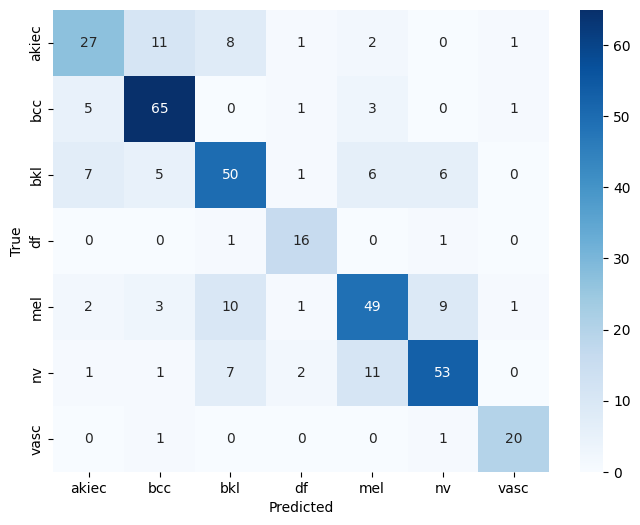

In [15]:
y_true, y_pred = [], []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(probs, axis=1))

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names, yticklabels=class_names,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


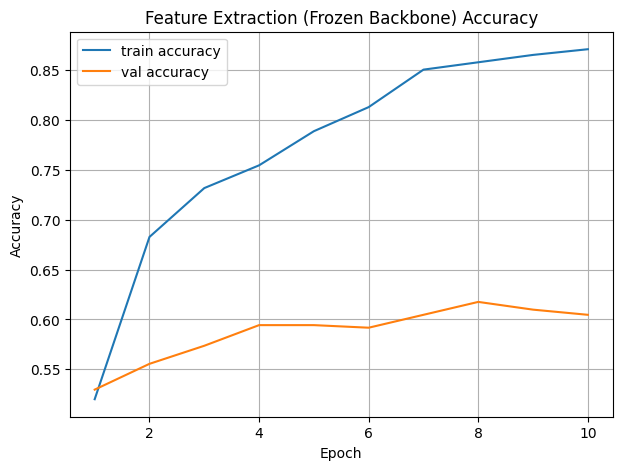

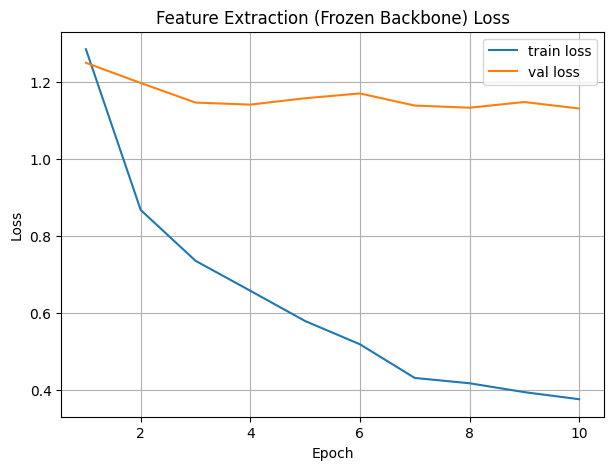

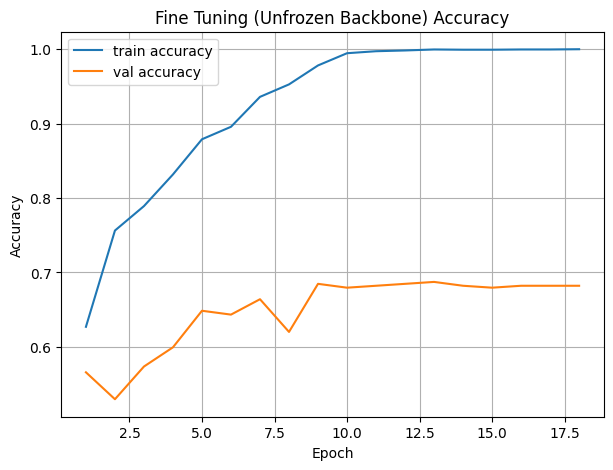

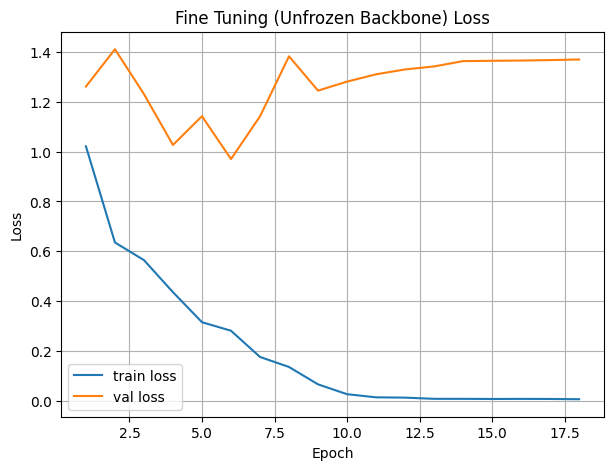

In [ ]:
def plot_history(h, title_prefix=""):
    hist = h.history
    epochs = range(1, len(hist["loss"]) + 1)

   
    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist["accuracy"], label="train accuracy")
    plt.plot(epochs, hist["val_accuracy"], label="val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    
    plt.figure(figsize=(7,5))
    plt.plot(epochs, hist["loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history, "Feature Extraction (Frozen Backbone)")
plot_history(history_fine, "Fine Tuning (Unfrozen Backbone)")


In [17]:
cm = confusion_matrix(y_true, y_pred)

specificity = []
for i in range(len(cm)):
    tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
    fp = np.sum(cm[:,i]) - cm[i,i]
    spec = tn / (tn + fp + 1e-9)
    specificity.append(spec)

for cls, spec in zip(class_names, specificity):
    print(f"{cls} Specificity: {spec:.4f}")


akiec Specificity: 0.9559
bcc Specificity: 0.9333
bkl Specificity: 0.9175
df Specificity: 0.9839
mel Specificity: 0.9302
nv Specificity: 0.9460
vasc Specificity: 0.9918


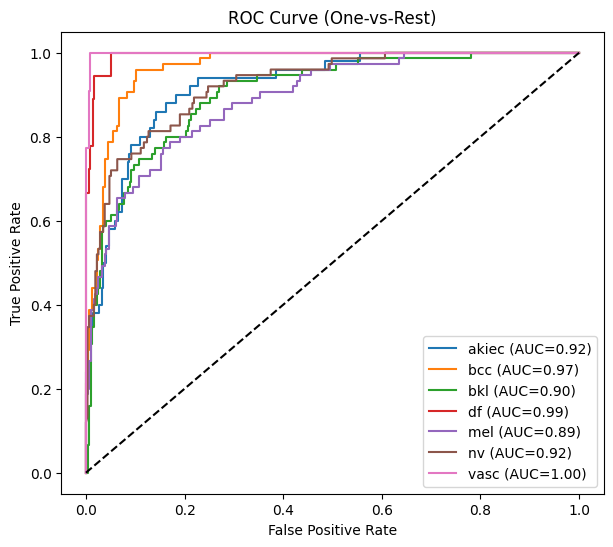

In [18]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

y_pred_prob = []
for images, _ in test_ds:
    y_pred_prob.extend(best_model.predict(images, verbose=0))
y_pred_prob = np.array(y_pred_prob)

plt.figure(figsize=(7,6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [19]:
macro_auc = roc_auc_score(
    y_true_bin,
    y_pred_prob,
    average="macro",
    multi_class="ovr"
)
print("Macro Average AUC:", macro_auc)

Macro Average AUC: 0.942474105190265


In [20]:
model.save_weights("ca.weights.h5")